In [2]:
import pandas as pd

df = pd.read_csv("cleaned_netflix_final.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,cast,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,cast,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df = df[['type', 'country', 'release_year', 'duration', 'rating']]

In [4]:
df = df.fillna("Unknown")

In [5]:
yearly_content = df.groupby('release_year').size().reset_index(name='total_content')

yearly_content.head()

,release_year,total_content
0,1925,1
1,1942,2
2,1943,3
3,1944,3
4,1945,4


In [6]:
X = yearly_content[['release_year']]

y = yearly_content['total_content']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
from xgboost import XGBRegressor

model = XGBRegressor()

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [10]:
predictions = model.predict(X_test)

print(predictions)

[  2.9992092 193.99483     2.0061436   2.008042    7.006314  953.00287
   2.9831338  12.949799    1.0077223  50.970562  237.00526     7.006314
   2.9831338  23.006586    2.9992092]


In [11]:
from sklearn.metrics import mean_absolute_error

error = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", error)

Mean Absolute Error: 30.27062225341797


In [12]:
from sklearn.metrics import r2_score, mean_squared_error
mean_error = mean_squared_error(y_test, predictions)
r2_error = r2_score(y_test, predictions)

In [13]:
future_years = pd.DataFrame({
    'release_year': [2026, 2027, 2028, 2029, 2030]
})

future_predictions = model.predict(future_years)

print(future_predictions)

[953.00287 953.00287 953.00287 953.00287 953.00287]


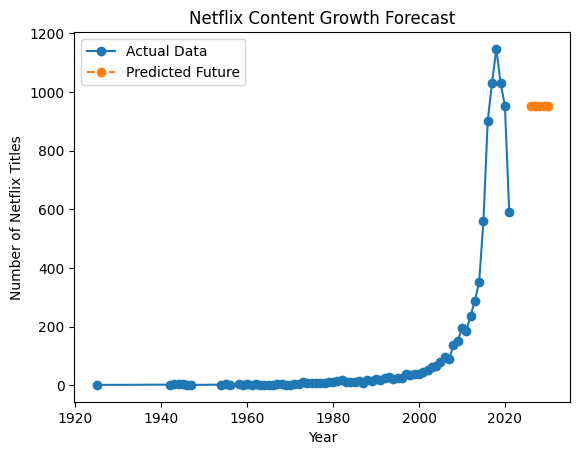

In [14]:
import matplotlib.pyplot as plt

# Actual historical data
plt.plot(
    yearly_content['release_year'],
    yearly_content['total_content'],
    marker='o',
    label='Actual Data'
)

# Future predictions
plt.plot(
    future_years['release_year'],
    future_predictions,
    marker='o',
    linestyle='dashed',
    label='Predicted Future'
)

plt.xlabel("Year")
plt.ylabel("Number of Netflix Titles")
plt.title("Netflix Content Growth Forecast")

plt.legend()

plt.show()

In [15]:
df['type_encoded'] = df['type'].map({
    'Movie': 0,
    'TV Show': 1
})

In [16]:
df[['type', 'type_encoded']].head()

,type,type_encoded
0,Movie,0
1,TV Show,1
2,TV Show,1
3,TV Show,1
4,TV Show,1


In [18]:
import gradio as gr
import pandas as pd

def predict_titles(year):

    input_data = pd.DataFrame({
        'release_year': [year]
    })

    prediction = model.predict(input_data)

    return int(prediction[0])

app = gr.Interface(
    fn=predict_titles,
    inputs=gr.Number(label="Enter Future Year"),
    outputs=gr.Number(label="Predicted Netflix Titles"),
    title="Netflix Forecast Model"
)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7ffb61f071ee3548c4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [19]:
df['type'].unique()

array(['Movie', 'TV Show'], dtype=object)